# **Korrupt Kódex**

<div style="font-size: 14px; color: #6e8192; line-height: 1.5;">
  <div style="display: flex; align-items: center; gap: 5px; margin-bottom: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🎯</span>
    <span>MI Országos Diákolimpia, Nyári Válogató</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🧠</span>
    <span>Machine Learning</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🏆</span>
    <span>100 pont</span>
  </div>
  <div style="display: flex; align-items: center; gap: 5px;">
    <span style="font-size: 18px; color: #6e8192;">🗓️</span>
    <span>2026. május</span>
  </div>
</div>

**Név:** [ÍRD IDE A NEVED]

**Versenyzői Azonosító (DOCK):** [ÍRD IDE A VERSENYZŐI AZONOSÍTÓD]


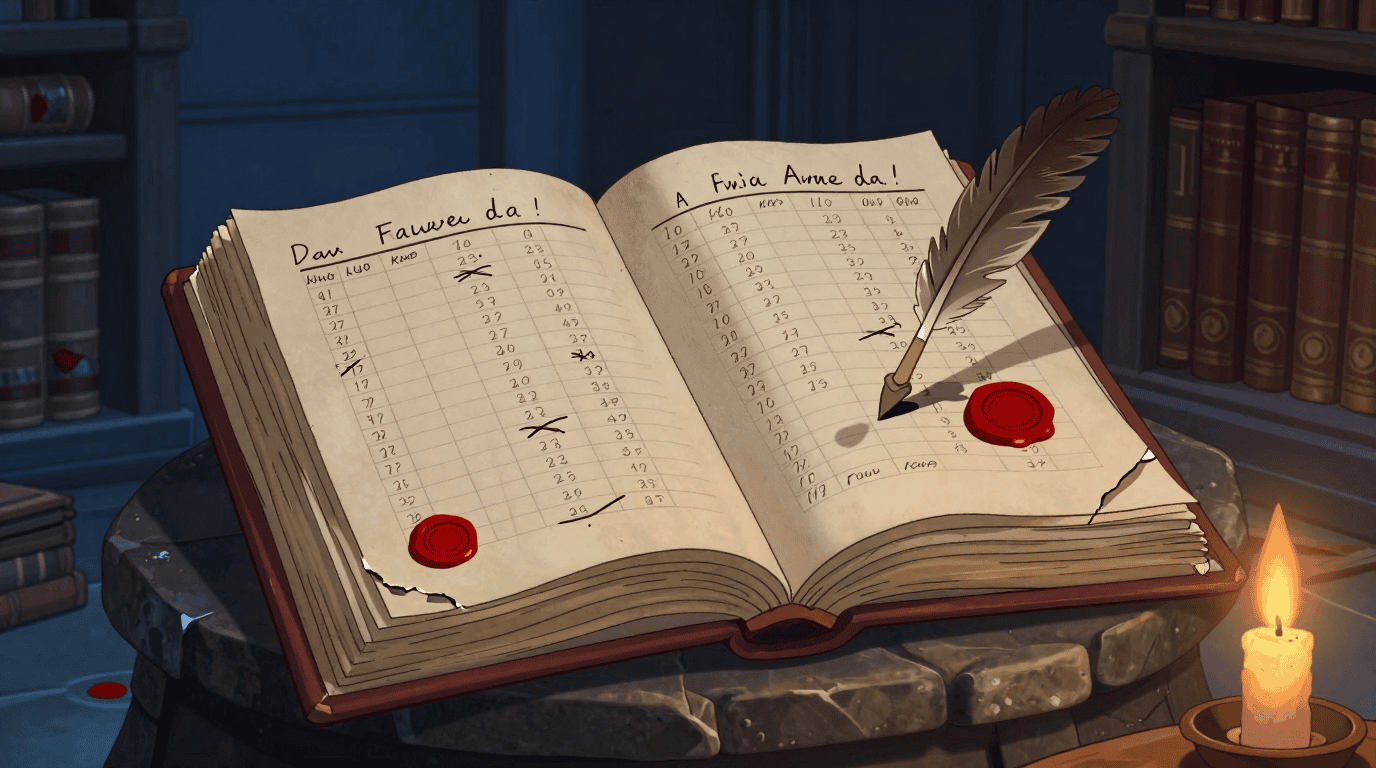

## **Feladatleírás**

Egy pénzügyi intézménynél csalásdetektáló rendszert üzemeltetnek. A rendszer szíve egy neurális
háló, amely 12 anonimizált jellemzőből megbecsüli, hogy egy adott tranzakció csalásgyanús-e
vagy legitim. A modellt korábban betanították, és azóta éles üzemben működik. A tanításhoz
felhasznált tranzakciós adatokat a szigorú belső adatmegőrzési és biztonsági szabályzatok
értelmében a megőrzési időszak lejárta után törölni kellett, így csak a betanított modell súlyai
maradtak meg.

Időközben kiderült, hogy a tanításhoz felhasznált adatok címkéi ismeretlen okokból helyenként
hibásak: a tanítóhalmazba bekerültek olyan minták, amelyek csalárd tranzakciókhoz tartoztak,
de legitimként szerepeltek.

A rendszer üzemeltetése során 5 000 olyan mintát gyűjtöttek össze, amelyekhez tartozó tranzakciókat
a modell legitimnek minősített, de felmerült a gyanú, hogy rejtett csalások is vannak
közöttük. Téged külső szakértőként kértek fel, hogy a modell vizsgálatából kiindulva derítsd ki,
mely minták származnak csalárd tranzakcióból. Mivel az eredeti tanítóadat nem áll rendelkezésre,
és a modellt nem lehet újratanítani, a vizsgálatot kizárólag a betanított háló viselkedéséből
kiindulva kell elvégezned.

**Amit kapsz:**

* `calibration.csv`: 50 címkézett mintából álló halmaz
* `test.csv`: 5000 címkézetlen mintából álló halmaz, ezen kell a predikciót elvégezni
* `net_weights.pt`: az előre tanított modell

**Amit beadsz:** egyetlen `submission.csv` fájl `id,score` fejléccel, pontosan 5000 értékelendő sorral. Az `id` 0..4999 sorszám, a `score` egy valós szám (nagyobb érték = nagyobb gyanú hibás címkére).

## **Hasznos Linkek**

- [PyTorch dokumentáció](https://pytorch.org/docs/stable/index.html)
- [NumPy dokumentáció](https://numpy.org/doc/stable/)
- [pandas dokumentáció](https://pandas.pydata.org/docs/)
- [AUC ROC (scikit-learn)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html)
- [ROC görbe](https://en.wikipedia.org/wiki/Receiver_operating_characteristic)

## **Szükséges Importok**

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# NE MÓDOSÍTSD: ezzel a seeddel kapod ugyanazt az eredményt minden
# újrafuttatáskor. A szerver determinisztikus.
# ═══════════════════════════════════════════════════════════════════
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

# --- Reprodukálhatóság: minden véletlent egyetlen seedhez kötünk ---
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# A feladat megoldásához GPU nem szükséges, de használható.
device = "cuda" if torch.cuda.is_available() else "cpu"
print('device:', device)

## **Fájlok letöltése**

Három fájlt töltünk le Google Drive-ról: a kalibrációs halmazt, a teszthalmazt és a betanított modell súlyait.

A cella biztonságosan fut Google Colabban és lokálisan is. Ha a `gdown` csomag nem elérhető, automatikusan telepíti; ha sikertelen (pl. internet nélküli környezetben), kiírja a manuális letöltési URL-eket. Ha a fájlok már a `data/` mappában vannak, a letöltést átugorja.

In [ ]:
import os
import subprocess
import sys
from pathlib import Path

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

# Egyenként töltjük le a 3 fájlt a Drive-ról. A FILE_ID-ket a szervezők adják meg.
FILES = {
    "calibration.csv": "1pwdxlA-aJ59eb8P3rlqRKjPKp4SS-Ugp",   # 50 címkézett minta
    "test.csv":        "1fkQ3IpdUfhJY46iPCShKOGjpd8W-rFmE",   # 5000 címkézetlen minta
    "net_weights.pt":  "1Lx1t3OYgvhDSU573asPcW8FGP90V18aX",   # betanított háló
}

missing = [name for name in FILES if not (DATA_DIR / name).exists()]

if not missing:
    print("Minden fájl megvan a data/ mappában, letöltés kihagyva.")
else:
    try:
        import gdown  # type: ignore
    except ImportError:
        try:
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
            import gdown  # type: ignore
        except Exception:
            gdown = None  # type: ignore

    if gdown is None:
        print("gdown nem elérhető. Töltsd le kézzel a következő fájlokat a data/ mappába:\n")
        for name in missing:
            print(f"  https://drive.google.com/uc?id={FILES[name]}  ->  data/{name}")
    else:
        for name in missing:
            file_id = FILES[name]
            target  = DATA_DIR / name
            try:
                gdown.download(id=file_id, output=str(target), quiet=False)
            except Exception as e:
                print(f"  {name} letöltése sikertelen: {e}")
                print(f"  manuális letöltés: https://drive.google.com/uc?id={file_id}")

for name in FILES:
    p = DATA_DIR / name
    print(f"  {p}: {'OK' if p.exists() else 'HIÁNYZIK'}")

## **Modell architektúra**

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(12, 256)
        self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, 1)

        # init params
        with torch.no_grad():
            self.fc1.weight.uniform_(-1 / 12, 1 / 12)

            bound2 = (6 / 256) ** 0.5 / 30
            self.fc2.weight.uniform_(-bound2, bound2)

            bound3 = (6 / 256) ** 0.5
            self.fc3.weight.uniform_(-bound3, bound3)

    def forward(self, x):
        x = torch.sin(30 * self.fc1(x))
        x = torch.sin(30 * self.fc2(x))

        return self.fc3(x)

## **Fájlok betöltése**

- `model`: előre tanított modell
- `X_calibration`: kalibrációs halmaz adatpontjai
- `X_test`: teszthalmaz adatpontjai
- `y_calibration`: kalibrációs halmaz címkéi

In [ ]:
model = Net().to(device)
model.load_state_dict(torch.load("data/net_weights.pt", map_location=device))

calibration_df = pd.read_csv("data/calibration.csv")
test_df = pd.read_csv("data/test.csv")

calibration = torch.tensor(calibration_df.values, dtype=torch.float32).to(device)
test = torch.tensor(test_df.values, dtype=torch.float32).to(device)

X_calibration = calibration[:, :-1]
y_calibration = calibration[:, -1]

X_test = test

## **Itt kezdődik a te kódod**

In [ ]:
# innentől írd a megoldásodat
print(X_calibration.shape)

neg_idx = torch.where(y_calibration == 0)
pos_idx = torch.where(y_calibration == 1)

print(model(X_calibration)[pos_idx])

# példa beadás, randomizált scoreok
scores = torch.randn(5000)

In [ ]:
submission = pd.DataFrame({
    "id":    torch.arange(5000),
    "score": scores,
})
submission.to_csv("submission.csv", index=False)

---

## 🎉 Sok sikert!

A `submission.csv` fájlt töltsd fel a **DOCK** platformra. Legfeljebb **15 feltöltési kísérleted** van, és a legjobb beadásod pontszáma számít.

---